### note
<br/>

### note name

In [1]:
# pip install ipynbname

import ipynbname
nb_name = ipynbname.name()
nb_path = ipynbname.path()

nb_name

'2Samples Classical_GRU_P441 SEEDs_ini_2'

## Hyper parameters

In [2]:
SEED = 2
# SEEDs = range(10) # 0~9
L_RATE = 0.2 # 0.2
N_STEPS = 1000000
NUM_SEEDs = 50

In [3]:
from jax.config import config
config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import pennylane as qml
from jax.example_libraries import optimizers
from jax.example_libraries import stax
from jax import value_and_grad
from jax import lax

import optax
# from functools import partial
import time
import matplotlib.pyplot as plt
import pickle


from SQGRU_j7x import SQGRU, qgru
from Classical_RNN import simple_rnn, gru, count_parameters

### force to use cpu

In [4]:
jax.config.update('jax_platform_name', 'cpu')

In [5]:
qml.version()

'0.31.1'

## Oscillations

In [6]:
def damped_shm(fre, damp):
    amp = 0.7
    num_data = 151
    x = jnp.array(range(num_data))
    y = jnp.sin(x*fre)*jnp.exp(x*damp)*amp

    return y

In [7]:
osc1 = damped_shm(0.4, 0)
osc2 = damped_shm(0.6, -0.02)

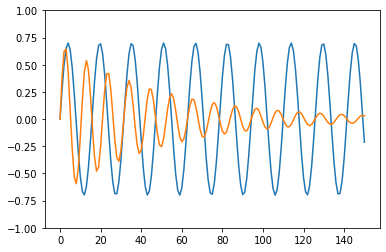

In [8]:
plt.plot(osc1)
plt.plot(osc2)
plt.ylim(-1,1)
plt.show()

In [9]:
oscillations = jnp.array([osc1,osc2])
true_data = jnp.expand_dims(oscillations, 2)
train_input = true_data[:,0:100,:]
train_target = true_data[:,1:101,:]

## Model
### Hyper parameters

In [10]:
# model parameters
OUT_DIM = 11

In [11]:
init_fun, qgru_rnn = stax.serial(gru(OUT_DIM, sequence_out=True), stax.Dense(1))

In [12]:
key = jax.random.PRNGKey(SEED)
key1, key2 = jax.random.split(key, num=2)
_, params = init_fun(key1, jnp.shape(train_input))

In [13]:
count_parameters(params)

441

## Train

In [14]:
step_size = L_RATE
optimizer = optax.adam(step_size)
opt_state = optimizer.init(params)

In [15]:

@jax.jit
def loss_fn(params, xs, ys):
#     prediction = qgru_rnn(params, xs)[:,:,0:1]
    prediction = qgru_rnn(params, xs)
#     prediction = cls_predict(xs, 10, params)
    
    return jnp.mean((prediction - ys)**2) # the prediction shape


# def update(i_step, params, xs, ys, opt_state):
#     loss, grads = value_and_grad(loss_fn)(params, xs, ys)
#     updates, opt_state = optimizer.update(grads, opt_state)
#     params = optax.apply_updates(params, updates)
#     return params, opt_state, loss


In [16]:
minLoss = 1000
best_params = params
lossList = []
loc_params_list = []
reset_steps = []

In [17]:
def ck_lr(old_lr, new_lr):
    d_lr = old_lr - new_lr
    return d_lr >= 0 and d_lr/new_lr < 1e-2

### prediction

In [18]:
_, qgru_rnn2 = stax.serial(gru(OUT_DIM, sequence_out=True), stax.Dense(1))

In [19]:
@jax.jit
def jit_rnn(params, inputs):
    return qgru_rnn2(params, inputs)

In [20]:
true1 = true_data.squeeze()[:,0:100]
true2 = true_data.squeeze()[:,100:]
xs = train_input

In [21]:
# for classical rnn to predict the trend
def cls_predict(inp, pred_length, params):
    ys = jit_rnn(params, inp)
    new_inp = inp
    for _ in range(pred_length-1):
        new_inp = jnp.concatenate([new_inp, ys[:,-1:]], axis=1)
        ys = jit_rnn(params, new_inp)
    return ys

### start

In [22]:
update_lr = True
lr_factor = 1
locLossList = [1000,1000,1000]
locLoss = 1000
loc_params = params



start = time.time()
for i in range(N_STEPS):
    
    if update_lr != 0:
        if update_lr < 0:
            params = loc_params
        else:
            locLossList = [1000,1000,1000]
            locLoss = 1000
            loc_params_list.append(loc_params)
            reset_steps.append(i)
            # reset parameters
            key1, key2 = jax.random.split(key2, num=2)
            _, params = init_fun(key1, jnp.shape(train_input))
            loc_params = params
            # stop when collect X local best parameters
            if len(loc_params_list) > NUM_SEEDs:
                break
        update_lr = 0
            
        # update learning rate
        optimizer = optax.adam(step_size)
        opt_state = optimizer.init(params)
        
        print('learning rate:', step_size)

        def update(i_step, params, xs, ys, opt_state):
            loss, grads = value_and_grad(loss_fn)(params, xs, ys)
            updates, opt_state = optimizer.update(grads, opt_state)
            params = optax.apply_updates(params, updates)
            return params, opt_state, loss
    
    pre_params = params
    params, opt_state, loss = update(i, params, train_input, train_target, opt_state)
    print('{}: {}   {} sec      '.format(i, loss, time.time()-start), end='\r')
    if loss < minLoss:
        best_params = pre_params
        minLoss = loss
    if loss < locLoss:
        loc_params = pre_params
        locLoss = loss
    if (i+1) % 100 == 0:
        # update learning rate?
        if loss > locLossList[0] and locLossList[1] > locLossList[0] and locLossList[2] > locLossList[0]:
            step_size /= 2
            update_lr = -1
        elif ck_lr(locLossList[2], loss) and ck_lr(locLossList[1], locLossList[2]) and ck_lr(locLossList[0], locLossList[1]):
            # reset
            step_size = L_RATE
            update_lr = 1
        locLossList[0] = locLossList[1]
        locLossList[1] = locLossList[2]
        locLossList[2] = loss
        
        
        lossList.append(loss)
        print('{}: {}   {} sec      '.format(i, loss, time.time()-start))

learning rate: 0.2
99: 0.0005516546225098949   1.7783887386322021 sec      
199: 0.0018204356147795162   2.537153482437134 sec        
299: 0.000295413535928108   3.312211036682129 sec         
399: 0.0002642269588294214   4.029646873474121 sec        
499: 0.0002432187227431392   4.783469200134277 sec        
599: 0.000224165125401098   5.544690847396851 sec         
699: 0.026825940310954647   6.3837573528289795 sec        
799: 0.00044744498847130467   7.074832916259766 sec       
899: 0.000849112700160735   7.809659719467163 sec         
learning rate: 0.1
999: 0.0006409605168659678   8.554261207580566 sec        
1099: 0.000375204025525005   9.310017824172974 sec        
1199: 0.0002788418133897859   10.024080753326416 sec       
1299: 0.00021109987911353774   10.766282796859741 sec      
1399: 0.00017466526840605943   11.481906414031982 sec      
1499: 0.0001452779296435513   12.204454898834229 sec       
1599: 0.00011859179199269002   12.940454721450806 sec      
1699: 9.9688939

26499: 3.398998356332284e-05   235.70435619354248 sec       
26599: 4.282150580306947e-05   236.9576334953308 sec        
26699: 3.417579407190777e-05   238.07475399971008 sec       
26799: 3.356867779503584e-05   239.10647416114807 sec       
26899: 3.341521498905924e-05   240.09806036949158 sec       
26999: 3.639092428727112e-05   241.14185047149658 sec       
27099: 3.3582660004595584e-05   242.31169819831848 sec      
27199: 3.336082742246627e-05   243.32412481307983 sec       
27299: 3.328091449744729e-05   244.3537151813507 sec        
27399: 6.359807539662411   245.439843416214 sec             
27499: 0.12730481172270705   246.53931307792664 sec      
27599: 0.1213076466882271   247.74985814094543 sec       
learning rate: 0.1
27699: 0.07653428264886317   248.7460811138153 sec        
27799: 0.06835172492652922   249.76510334014893 sec      
27899: 0.06628721916995838   250.78548121452332 sec      
27999: 0.06526449223217129   251.77761459350586 sec      
28099: 0.0646707673169

52799: 8.945716954283437e-05   574.2972793579102 sec       
52899: 7.677623653339228e-05   575.6442575454712 sec       
52999: 5.855501879053271e-05   576.969274520874 sec        
53099: 6.985884358579976e-05   578.2698559761047 sec       
53199: 5.6023526454982034e-05   579.6030797958374 sec      
53299: 4.434105552191577e-05   581.068418264389 sec        
53399: 4.112473350349751e-05   582.4341552257538 sec       
53499: 5.331269028733875e-05   583.8748574256897 sec       
53599: 3.656741938119376e-05   585.2583191394806 sec       
53699: 3.9263061098009356e-05   586.6305868625641 sec      
53799: 3.54975675335767e-05   588.0937538146973 sec        
53899: 3.7234934158058324e-05   589.4694895744324 sec      
53999: 3.500472706062292e-05   590.8266158103943 sec       
54099: 3.72071519778251e-05   592.1806311607361 sec        
54199: 3.47535022538946e-05   593.4699032306671 sec        
54299: 6.307757698299043e-05   594.8996374607086 sec       
54399: 3.486227714522269e-05   596.33077

79299: 3.453231580076433e-05   924.5506513118744 sec       
79399: 3.4161840884406404e-05   925.8464248180389 sec      
79499: 3.3910996506361666e-05   927.095064163208 sec       
79599: 3.3735552077234204e-05   928.3322386741638 sec      
79699: 3.3609364464599156e-05   929.5156009197235 sec      
learning rate: 0.2
79799: 0.0003714939772565389   930.7069730758667 sec       
79899: 0.00015886739277291414   931.9252078533173 sec      
79999: 0.0001094988515675331   933.2285392284393 sec       
80099: 8.409800260500377e-05   934.36989569664 sec         
80199: 8.589039791848602e-05   935.6327586174011 sec       
80299: 5.40767871725996e-05   936.9045972824097 sec        
80399: 7.355182798784238e-05   938.1824040412903 sec       
80499: 3.976268034767989e-05   939.4564385414124 sec       
80599: 3.673468816127042e-05   940.6882147789001 sec       
80699: 3.5225790474246066e-05   941.9445204734802 sec      
80799: 3.8101178600975894e-05   943.2683615684509 sec      
80899: 3.491225657770

92399: 0.004261129898774723   1092.9128499031067 sec       
92499: 0.000484731802409943   1094.2419426441193 sec       
92599: 0.00037639551132413463   1095.5281755924225 sec      
92699: 0.00023709648436849993   1096.7975034713745 sec      
92799: 0.0024944308629961404   1098.07705616951 sec         
92899: 0.0001786714345985627   1099.3719654083252 sec       
92999: 0.00015483592431485909   1100.6363122463226 sec      
93099: 0.00014085724037040856   1101.8418741226196 sec      
93199: 0.00012971870795596907   1103.0859837532043 sec      
93299: 0.00011924308482815108   1104.3581414222717 sec      
93399: 0.1791191733278198   1105.638436794281 sec           
93499: 0.02873584841889056   1106.931788444519 sec        
93599: 0.021820497242195397   1108.2673089504242 sec      
learning rate: 0.1
93699: 0.0010671787065383023   1109.5453238487244 sec      
93799: 0.00048387669554385895   1110.8576242923737 sec      
93899: 0.0003760511686394484   1112.1299693584442 sec       
93999: 0.000

118799: 0.001141298585284077   1435.4828341007233 sec       
118899: 0.0010845850566025212   1436.9638102054596 sec      
118999: 0.007545964811362001   1438.4099583625793 sec       
119099: 0.0009864476864914437   1439.856823682785 sec       
119199: 0.0009299102060289627   1441.2428064346313 sec      
119299: 0.0008772235632325869   1442.6793439388275 sec      
119399: 0.0008577287283786455   1444.1784472465515 sec      
119499: 0.0007944071807670308   1445.846316576004 sec       
119599: 0.0007469003252854513   1447.4585189819336 sec      
119699: 0.0011329614384451737   1448.9270825386047 sec      
119799: 0.0006790765019764703   1450.3314564228058 sec      
119899: 0.0006360016542432534   1451.7431118488312 sec      
119999: 0.0012475965744757856   1453.2202370166779 sec      
120099: 0.0005775296331833568   1454.6963138580322 sec      
120199: 0.000538605029587102   1456.1754891872406 sec       
120299: 0.0005386066377642817   1457.663843870163 sec       
120399: 0.00048481702053

144499: 6.849437142873664e-05   1833.1079556941986 sec       
144599: 0.0005247769134367639   1834.5192499160767 sec       
144699: 6.154184305029885e-05   1835.9540655612946 sec       
144799: 7.440159674991064e-05   1837.4108917713165 sec       
144899: 0.00025676089301097677   1838.7935371398926 sec      
144999: 7.001033997691422e-05   1840.1429159641266 sec       
learning rate: 0.1
145099: 0.0009527492018013426   1841.6069657802582 sec      
145199: 0.0006103867794300057   1843.029205083847 sec       
145299: 0.00044287891931851775   1844.4935264587402 sec      
learning rate: 0.05
145399: 0.0003351290692200449   1845.9304032325745 sec       
145499: 0.00013149966405853018   1847.3015513420105 sec      
145599: 7.5544614940643e-05   1848.755178451538 sec          
145699: 5.870975676370041e-05   1850.1501767635345 sec       
145799: 5.147256237280515e-05   1851.635692358017 sec        
145899: 4.691357849729884e-05   1853.1967282295227 sec       
145999: 4.377531246237722e-05   1

170199: 3.691073276053648e-05   2203.9917254447937 sec       
learning rate: 0.025
170299: 4.995506906557509e-05   2205.553515434265 sec        
170399: 3.737437385476406e-05   2207.3673963546753 sec       
170499: 3.618432869862624e-05   2209.041734933853 sec        
170599: 3.556554117086635e-05   2210.5144770145416 sec       
170699: 3.513511518740481e-05   2212.1057415008545 sec       
170799: 3.481132812414432e-05   2213.672063112259 sec        
170899: 3.455881879085828e-05   2215.4568300247192 sec       
170999: 3.435533599024231e-05   2217.572948217392 sec        
learning rate: 0.2
171099: 0.0783738729507318   2219.321118116379 sec         
171199: 0.06551828137147676   2220.7748634815216 sec      
171299: 0.06257427345833422   2222.194380044937 sec       
171399: 0.0608456949561689   2223.7057359218597 sec        
171499: 0.05928472198752597   2225.149669647217 sec        
171599: 0.05783721357477724   2226.80854845047 sec         
171699: 0.05651501367980307   2228.288427591

196199: 3.438382495340975e-05   2580.138154745102 sec        
196299: 4.2283302726432106e-05   2581.475965976715 sec       
196399: 3.613515253557279e-05   2582.878381252289 sec        
196499: 3.486013380703587e-05   2584.4118926525116 sec       
learning rate: 0.1
196599: 0.019059435141663063   2585.9100744724274 sec       
196699: 0.016376466277189743   2587.3601055145264 sec      
196799: 0.013014257357813364   2588.744704723358 sec       
learning rate: 0.05
196899: 0.0001974689275358426   2590.141810655594 sec        
196999: 0.00011984538300763066   2591.5411479473114 sec      
197099: 8.408102321369312e-05   2592.8637890815735 sec       
197199: 6.588464632913291e-05   2594.250197172165 sec       
197299: 5.5766806228267484e-05   2595.6038150787354 sec      
197399: 4.946155242604204e-05   2596.867742538452 sec        
197499: 4.5174299028048205e-05   2598.2383439540863 sec      
197599: 4.212679098733389e-05   2599.5555663108826 sec       
197699: 3.997207246902357e-05   2600.

In [23]:
minLoss

Array(3.31056388e-05, dtype=float64)

In [24]:
# Save
# Loss, minLoss, params, best_params, loc_params_list, reset_steps
with open(nb_name+'_state.pkl', 'wb') as f:
    pickle.dump((lossList, minLoss, params, best_params, loc_params_list, reset_steps), f)

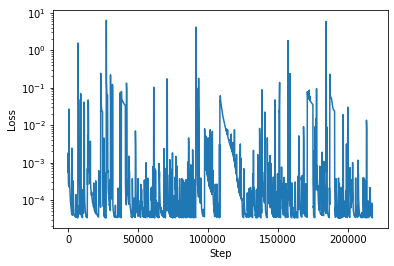

In [25]:
plt.plot([x*100 for x in range(len(lossList))], lossList)
plt.ylabel('Loss')
plt.xlabel('Step')
plt.yscale("log")
plt.show()

## Result

### best parameters

In [26]:
ys = cls_predict(xs, 50, best_params)

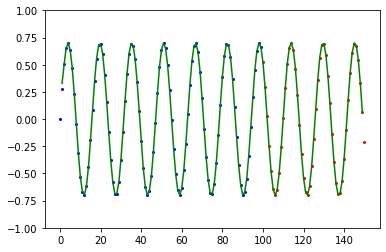

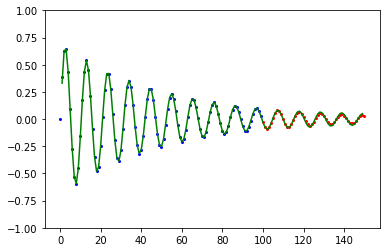

In [27]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

### final parameters

In [28]:
ys = cls_predict(xs, 50, params)

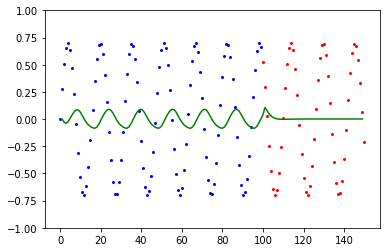

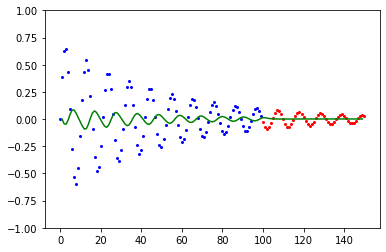

In [29]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

## Load & find the best parameters

In [22]:
# load
# Loss, minLoss, params, best_params, loc_params_list, reset_steps
with open(nb_name+'_state.pkl', 'rb') as f:
    lossList, minLoss, params, best_params, loc_params_list, reset_steps = pickle.load(f)

In [23]:
test_result = []
min_loss = 1000
k = 0
for i in reset_steps[1:]:
    k += 1
    j = int(i/100 -1)
    i_loss = lossList[j]
    i_params = loc_params_list[k]
    
    ys = cls_predict(xs, 50, i_params)
    
    t_loss = jnp.mean((true2[:,:-1]-ys[:,-50:,0])**2)
    test_result.append([i,i_loss,t_loss,i_params,ys])
    if t_loss < min_loss:
        min_loss = t_loss
        min_idx = k-1
        min_ys = ys
        
test_result[min_idx]

[62100,
 Array(3.32296066e-05, dtype=float64),
 Array(2.04907745e-05, dtype=float64),
 [((Array([[ 0.67876449,  0.57968399, -0.89497837,  1.67423963, -0.66772484,
            -0.40227066,  0.55620879, -0.2752022 , -0.04299091, -2.35514233,
            -0.94768415]], dtype=float64),
    Array([[ 1.16833860e+00, -2.03986895e+00,  4.89012657e-01,
            -2.52316163e+00,  5.86753169e-01, -1.41521931e+00,
             1.66807073e-01,  2.10926330e+00,  1.90270468e+00,
             3.48789559e-01,  1.18724440e+00],
           [ 6.43240053e-01,  3.77128759e-01, -1.61280387e+00,
             1.61824096e+00,  2.99343865e-02, -1.39795978e+00,
            -1.48217846e+00, -1.36281471e+00, -1.34192464e+00,
            -1.45816081e+00, -1.13998879e+00],
           [ 8.88729835e-01, -8.10902051e-01, -9.94974556e-02,
             1.66212631e+00, -2.20629927e-01, -1.11807250e+00,
             5.79057756e-01,  3.67767785e-01,  3.57998628e-01,
             1.13198814e+00,  8.98142979e-01],
         

In [24]:
# Save results
# [[i,i_loss,t_loss,i_params,ys]...]
with open(nb_name+'_test_result.pkl', 'wb') as f:
    pickle.dump(test_result, f)

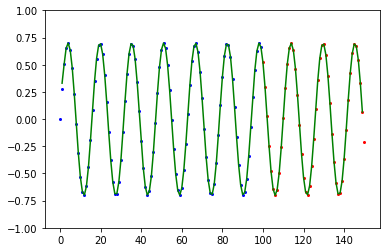

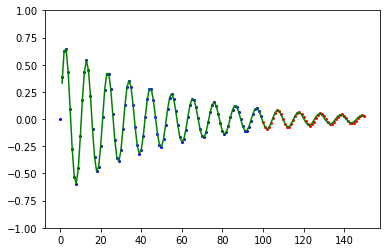

In [32]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(min_ys[idx])))+1, min_ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

best: [62100, Array(3.32296066e-05, dtype=float64), Array(2.04907745e-05, dtype=float64)]
5500 3.4865814307038844e-05 0.19625843996457273


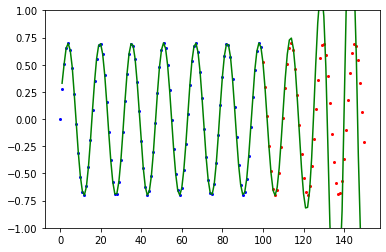

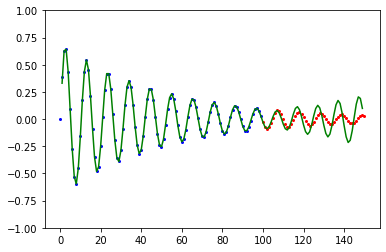

7900 0.04688962776494465 0.0006003552931696372


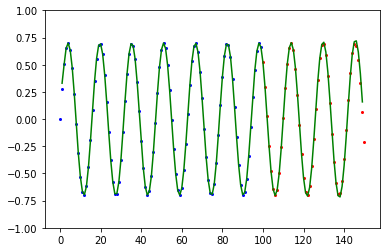

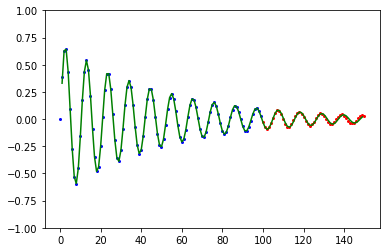

10400 3.382373775741379e-05 0.004131557413868756


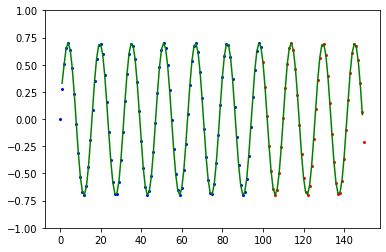

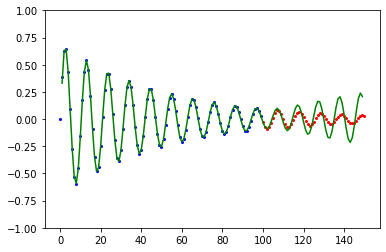

13800 3.350929474162833e-05 9.629890850287859e-05


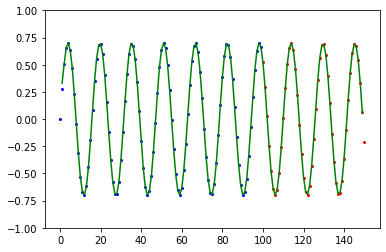

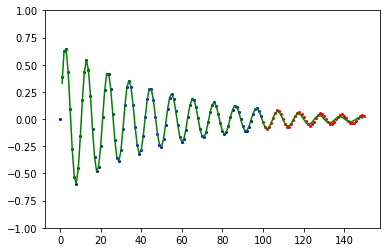

21900 3.495840232100286e-05 0.0012567636898045736


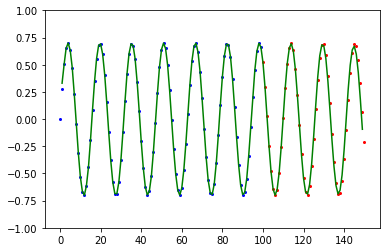

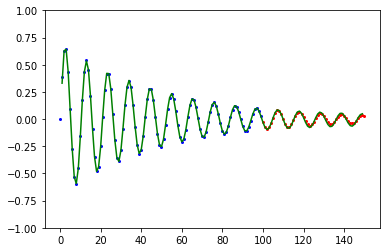

24700 0.0231975995141162 0.0026768740531604917


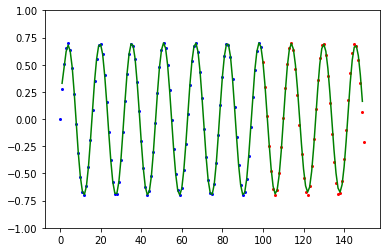

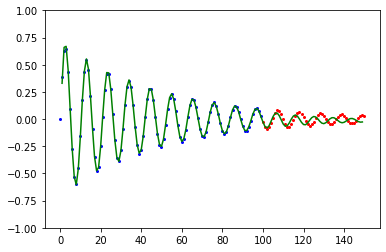

28300 0.06419586054175054 0.09285769864362234


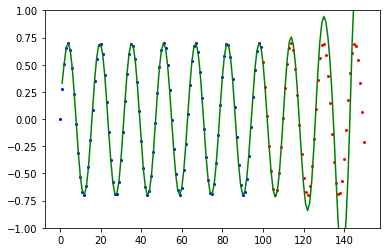

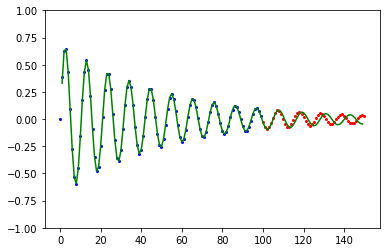

35600 3.400235726309506e-05 0.0020829535016208913


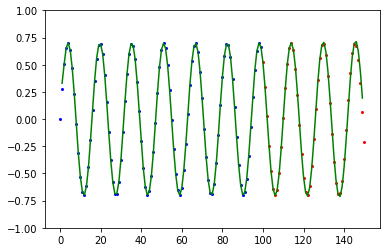

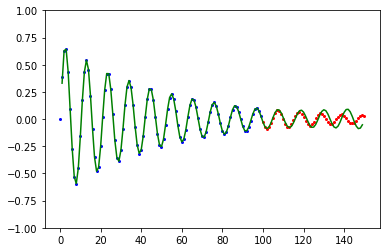

38100 3.342532254383408e-05 0.00014776686758479317


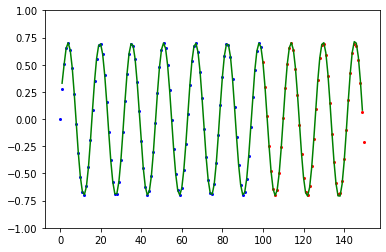

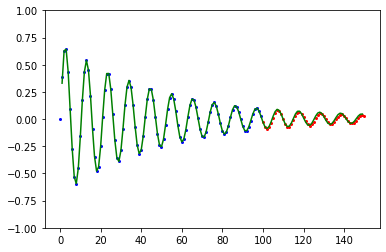

41000 0.03343165435577657 0.5738196795061101


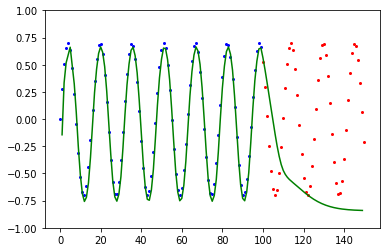

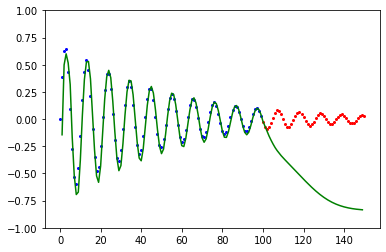

45900 3.348338385746637e-05 6.732256969831084e-05


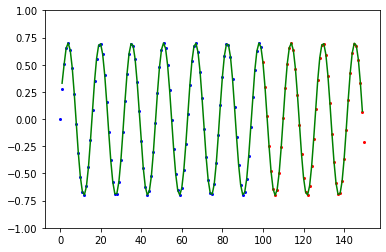

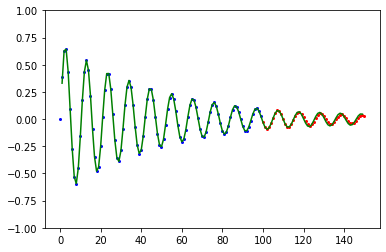

52000 3.415880068943717e-05 0.002865092031495135


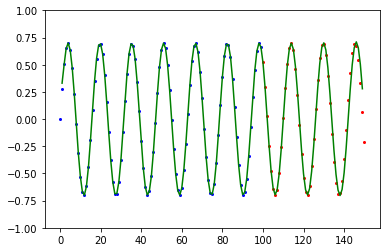

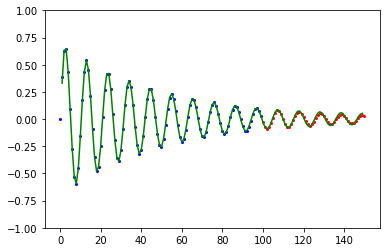

55600 3.326088570751455e-05 0.028708828262800967


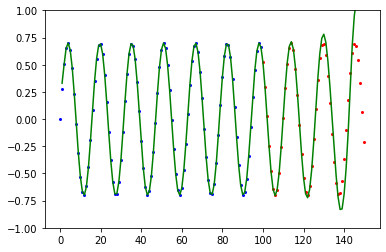

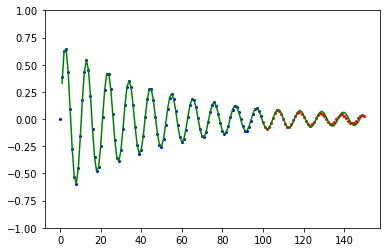

59500 3.377892359223035e-05 0.00030938915459046974


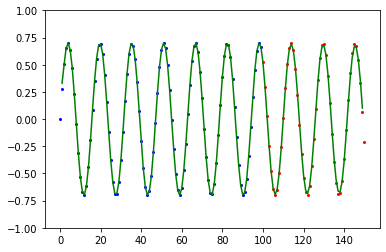

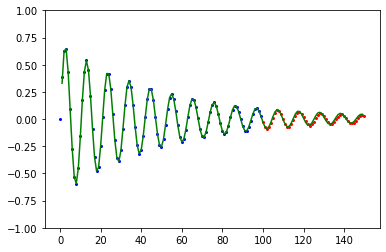

62100 3.3229606621162126e-05 2.0490774481352347e-05


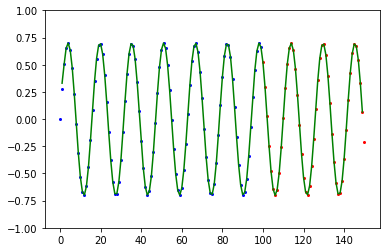

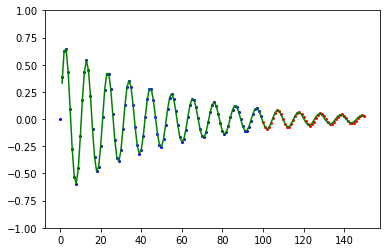

69700 3.328966703345865e-05 0.00032247310276744645


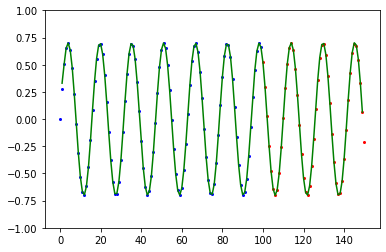

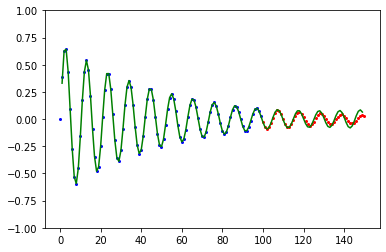

76600 3.3440582729176285e-05 0.001237217320992761


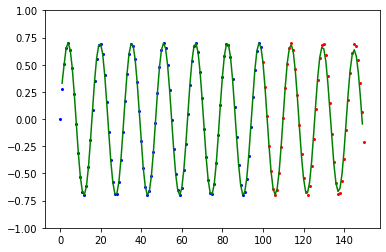

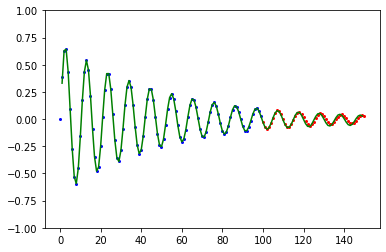

79700 3.3609364464599156e-05 0.00560500762016451


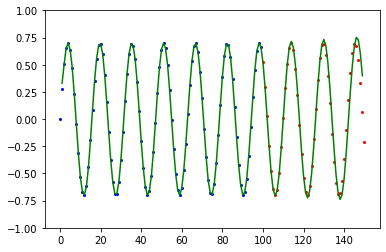

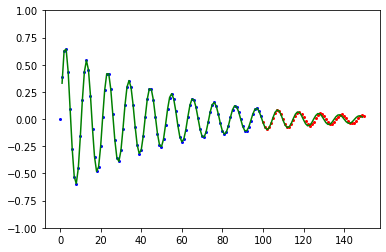

81300 3.3655753374600675e-05 0.0004219293929092058


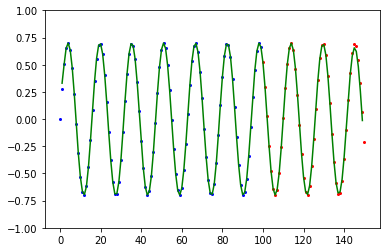

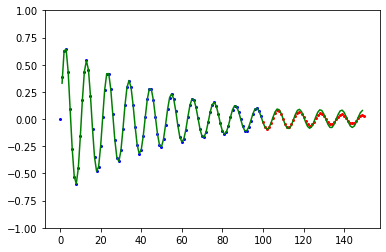

84400 3.341650829433261e-05 0.0004022729643894498


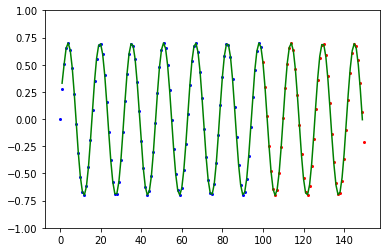

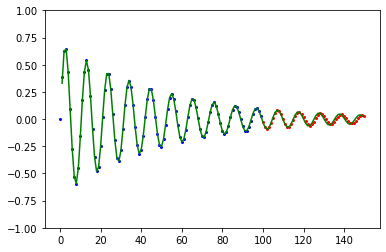

87200 3.372347876414561e-05 0.00034378991923845055


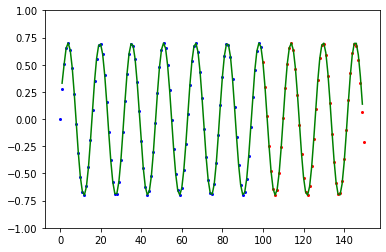

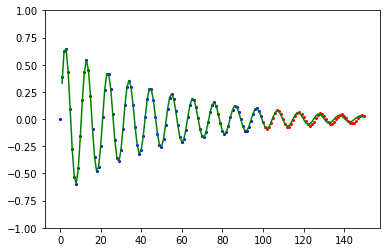

90000 3.328870562492272e-05 0.0002443388559696128


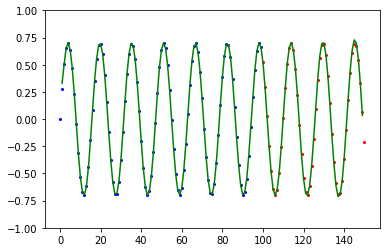

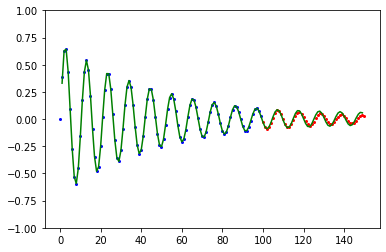

92300 0.09395251649806 0.0005383549731254034


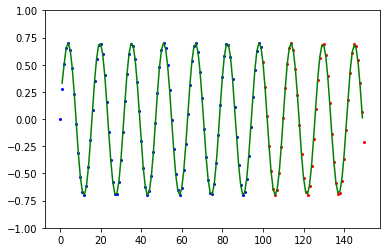

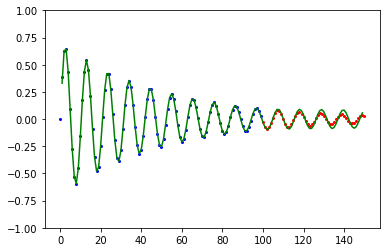

97600 3.543961911249761e-05 0.32388749927143934


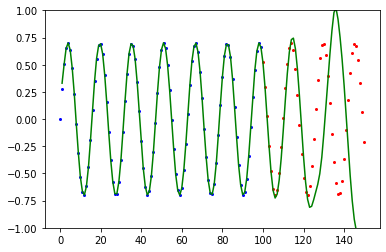

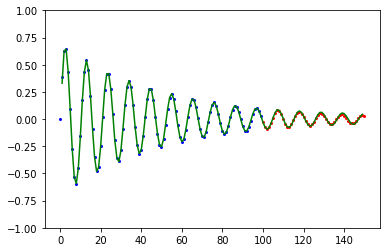

106500 3.392126104358161e-05 0.0001856737336066368


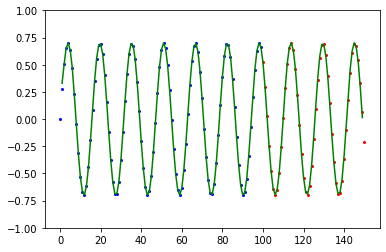

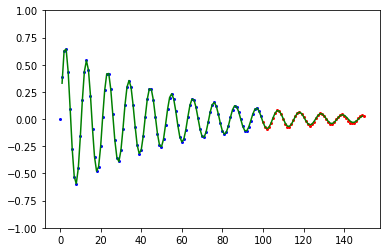

125600 3.345608334123021e-05 7.781086694284292e-05


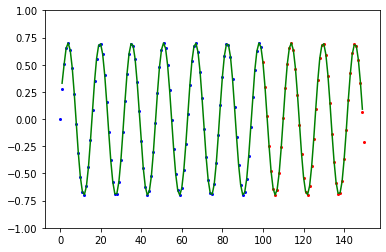

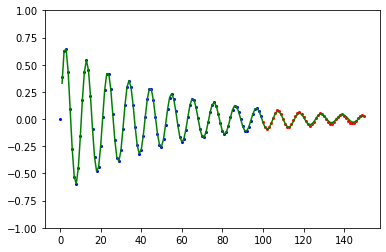

129400 3.396270610154233e-05 0.001291035606582397


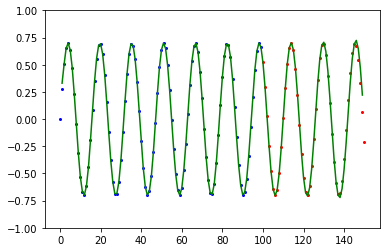

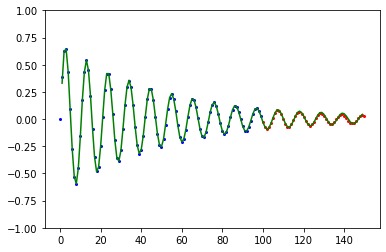

132000 3.371590952535934e-05 0.0005743759245931972


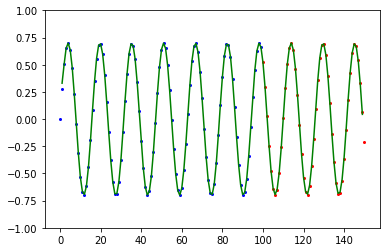

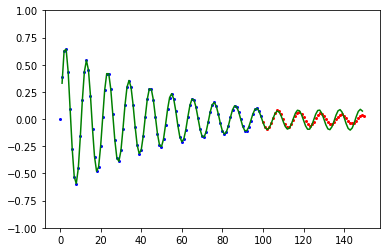

135400 3.3290069844164484e-05 0.001852687503629337


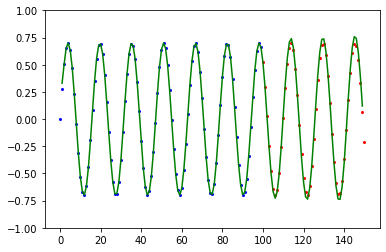

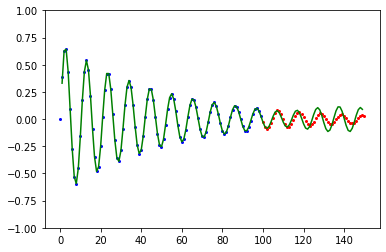

138000 3.339922181509901e-05 0.010449025692269649


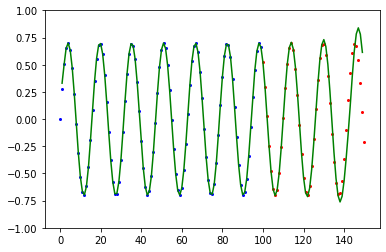

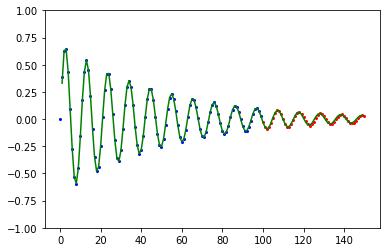

142400 3.363457219663571e-05 0.001328586868159729


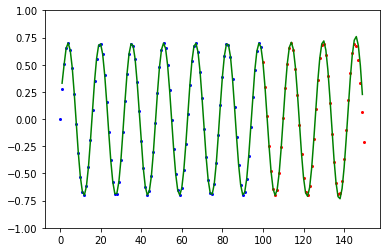

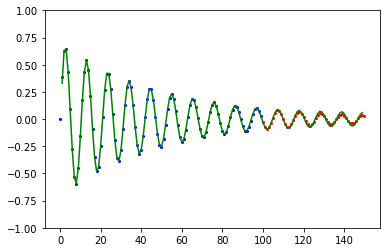

149000 3.4121357700832876e-05 0.0004185649521741981


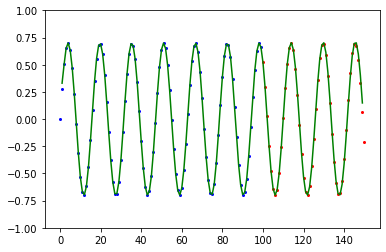

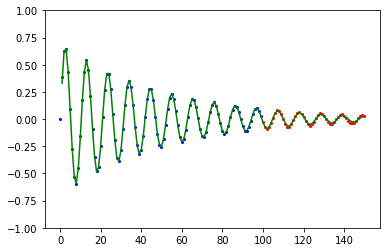

152000 3.343157943997727e-05 0.28328178198424353


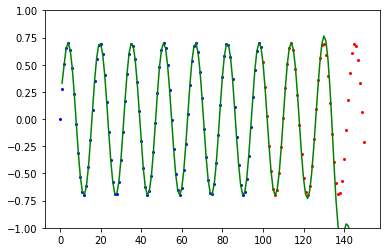

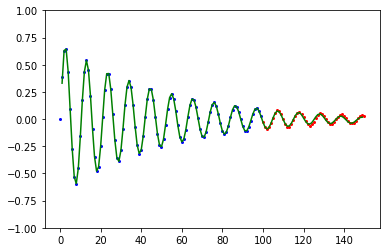

155800 3.352410140944113e-05 0.0008009297146034672


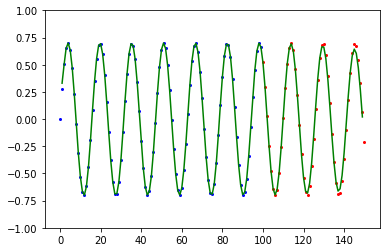

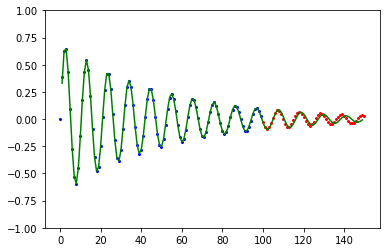

160000 3.344272864751572e-05 0.0009134246064659543


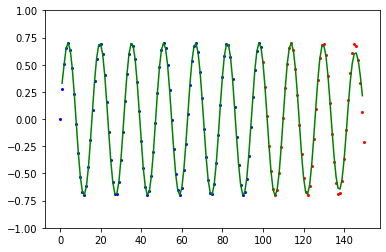

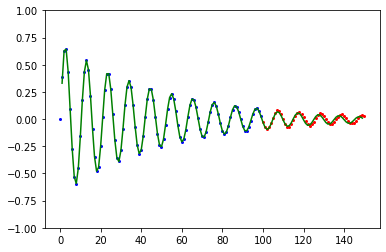

164300 3.3165327045099435e-05 2.0558539412561186e-05


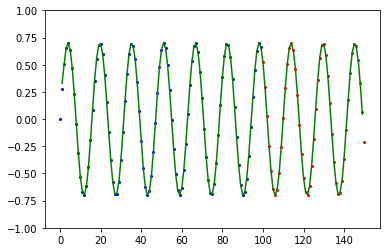

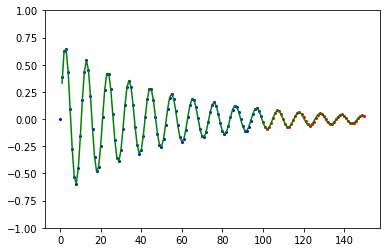

167200 3.465105998699581e-05 0.0031706863676066637


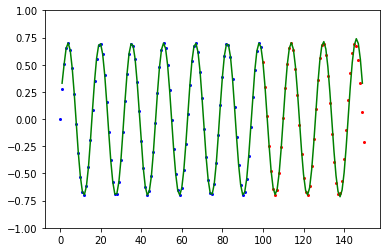

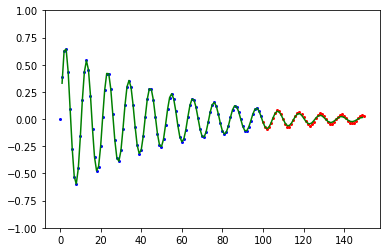

171000 3.435533599024231e-05 0.008141159763145975


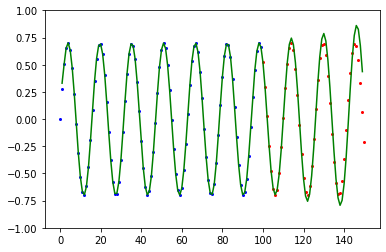

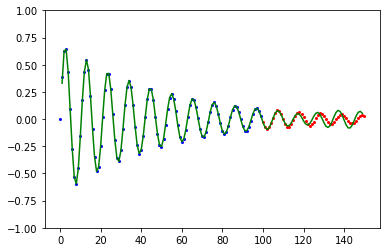

175100 0.03544641286307411 0.14328794667670006


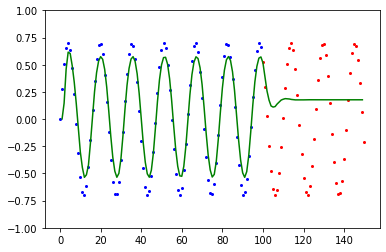

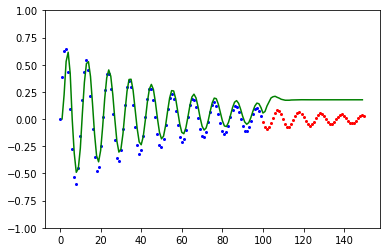

176500 3.348272974934096e-05 0.000973580786530916


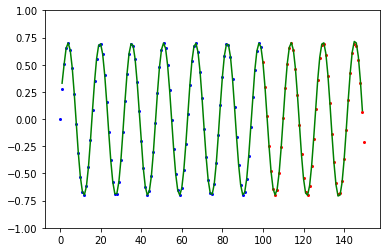

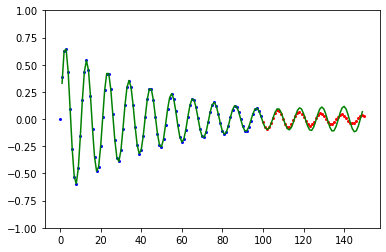

182800 3.813394332799048e-05 3.415205089888341


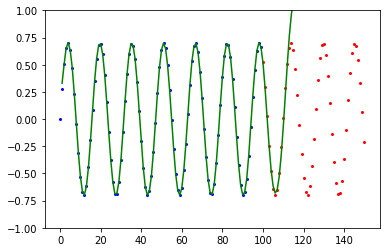

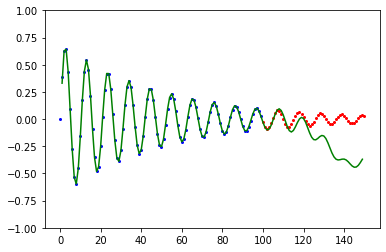

186800 3.365446982490252e-05 0.005410206840882515


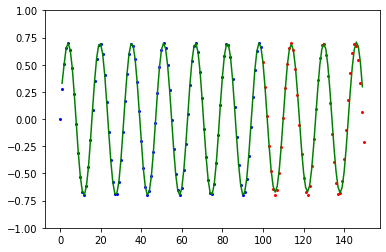

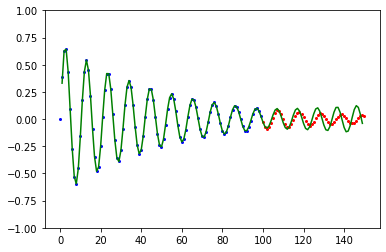

190600 0.023876489744160963 0.012862326401250884


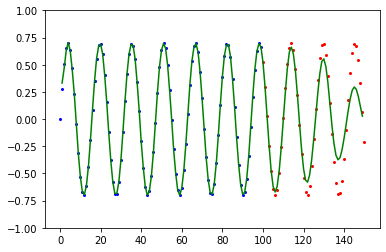

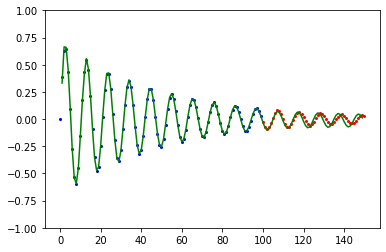

195300 3.311387838692917e-05 4.090633316279141e-05


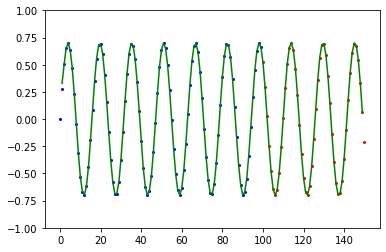

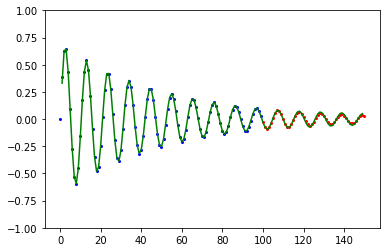

198800 3.459458361734925e-05 0.03151694002308846


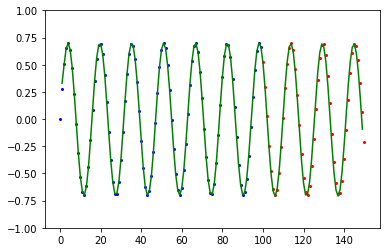

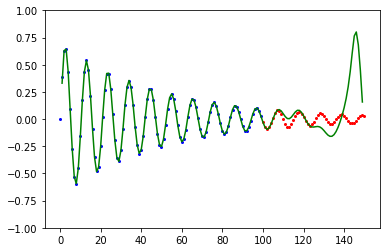

201600 3.4188358297109266e-05 0.0013325926970739488


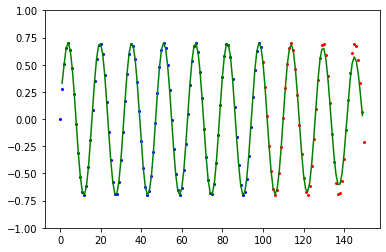

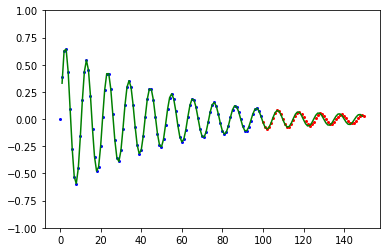

205500 3.4094250430533084e-05 0.29846842464809403


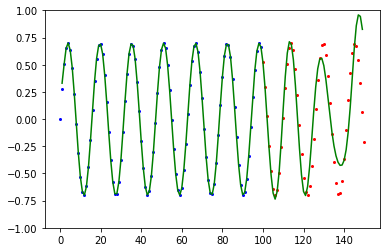

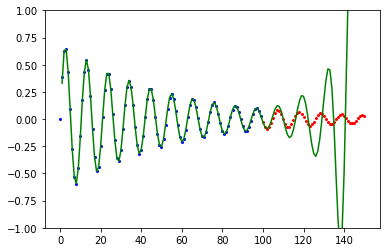

210900 3.3521333309834593e-05 2.8676282906840096e-05


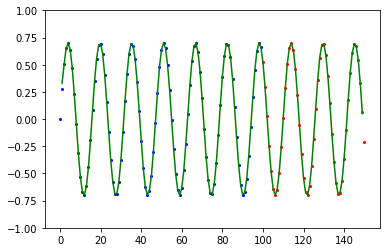

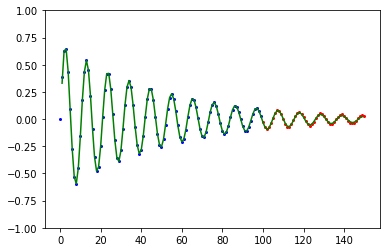

214500 3.348906789146135e-05 4.574059455962096e-05


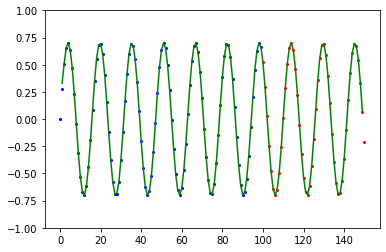

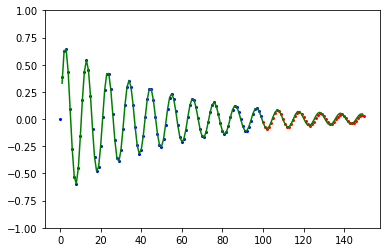

217700 3.3615975793752965e-05 0.0011734795457452808


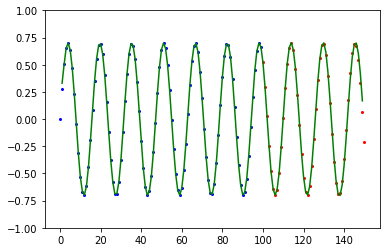

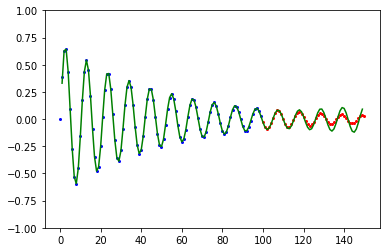

In [33]:
print('best:', test_result[min_idx][0:3])
for pak in test_result:
    i, i_loss, t_loss, _, ys = pak
    print(i, i_loss, t_loss)
    for idx in [0, 1]:
        plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
        plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
        plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
        plt.ylim(-1,1)
        plt.show()

In [34]:
sum([_[2] for _ in test_result])/len(test_result)

Array(0.10923509, dtype=float64)

In [35]:
len(test_result)

50